In [ ]:
import pandas as pd

In [2]:
docs_df = pd.read_csv('results/topics/document_topics_20250630_151939.csv')
topics_df = pd.read_csv('results/topics/topic_info_20250630_151939.csv')


/var/folders/kx/_tc54hxs4vvg1vg8844xqvqm0000gn/T/ipykernel_79935/2185927744.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  docs_df = pd.read_csv('results/topics/document_topics_20250630_151939.csv')


In [20]:
docs_df.to_csv('data/cleaned/documents_topics.csv')

In [4]:
topics_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1916 entries, 0 to 1915
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Topic                1916 non-null   int64 
 1   Count                1916 non-null   int64 
 2   Name                 1916 non-null   object
 3   Representation       1916 non-null   object
 4   Representative_Docs  1916 non-null   object
dtypes: int64(2), object(3)
memory usage: 75.0+ KB


In [7]:
topics_df.head(10)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,165060,-1_models_spectral_stochastic_optimal,"['models', 'spectral', 'stochastic', 'optimal'...","[""A PDE approach for solving the characteristi..."
1,0,2007,0_reed solomon codes_solomon codes_codes const...,"['reed solomon codes', 'solomon codes', 'codes...",['AG Codes Achieve List-decoding Capacity over...
2,1,1557,1_nonlinear schr odinger_schr odinger equation...,"['nonlinear schr odinger', 'schr odinger equat...","['Decay estimates for nonlinear Schr\\""odinger..."
3,2,1483,2_von neumann algebras_von neumann algebra_neu...,"['von neumann algebras', 'von neumann algebra'...",['The weak tracial Rokhlin property for finite...
4,3,1449,3_partially hyperbolic_topological entropy_uni...,"['partially hyperbolic', 'topological entropy'...",['SRB measures for mostly expanding partially ...
5,4,1371,4_enriched categories_infty categories_monoida...,"['enriched categories', 'infty categories', 'm...","[""An equivalence between enriched $\\infty$-ca..."
6,5,1366,5_randomized kaczmarz_sparse matrix_krylov sub...,"['randomized kaczmarz', 'sparse matrix', 'kryl...",['Parallelization Strategies for the Randomize...
7,6,1125,6_banach lattices_operators banach spaces_bana...,"['banach lattices', 'operators banach spaces',...",['Unbounded continuous operators and unbounded...
8,7,1085,7_coloring graphs_edge colorings_vertex colori...,"['coloring graphs', 'edge colorings', 'vertex ...",['New bounds on the anti-Ramsey numbers of sta...
9,8,1025,8_elliptic equations_laplacian_normalized solu...,"['elliptic equations', 'laplacian', 'normalize...","['Positive normalized solutions of Schr\\""{o}d..."


In [10]:
import json
import pandas as pd

# --- Step 1: Load the JSON file into a Python dictionary ---
# This step is the same as before.
try:
    with open('results/topics/topic_keywords_20250630_151939.json', 'r') as f:
        keywords_dict = json.load(f)
    print("Successfully loaded topic_keywords.json")
except FileNotFoundError:
    print("Error: topic_keywords.json not found. Please check the path.")
    # Create a dummy dictionary to allow the rest of the script to run for demonstration
    keywords_dict = {
        "0": [["group theory", 0.85], ["finite groups", 0.76]],
        "1": [["differential geometry", 0.91], ["riemannian manifolds", 0.82]]
    }

# --- Step 2: Process the dictionary into the desired DataFrame structure ---

# We will create a list of records (dictionaries), which is an efficient way to build a DataFrame.
records = []
for topic_id, keywords_with_scores in keywords_dict.items():
    # The keywords_with_scores is already a list of lists, which is close to a list of tuples.
    # We can convert it to a list of tuples for consistency, though it's not strictly necessary.
    keyword_tuples = [tuple(item) for item in keywords_with_scores]
    
    records.append({
        'topic': int(topic_id),
        'keywords': keyword_tuples  # Assign the list of tuples directly
    })

# Create the DataFrame from our list of records
keywords_df = pd.DataFrame(records)

# --- Step 3: Verify the result ---

print("\nDataFrame Info:")
keywords_df.info()

print("\nFirst 5 rows of the new DataFrame:")
print(keywords_df.head())

# Let's inspect the data type of the 'keywords' column and an example cell
print(f"\nType of the 'keywords' column: {type(keywords_df['keywords'])}")
if not keywords_df.empty:
    print(f"Type of a cell in 'keywords' column: {type(keywords_df.loc[0, 'keywords'])}")
    print(f"Content of first cell: {keywords_df.loc[0, 'keywords']}")

Successfully loaded topic_keywords.json

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1915 entries, 0 to 1914
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   topic     1915 non-null   int64 
 1   keywords  1915 non-null   object
dtypes: int64(1), object(1)
memory usage: 30.1+ KB

First 5 rows of the new DataFrame:
   topic                                           keywords
0      0  [(reed solomon codes, 0.6646755337715149), (so...
1      1  [(nonlinear schr odinger, 0.7245205640792847),...
2      2  [(von neumann algebras, 0.6377335786819458), (...
3      3  [(partially hyperbolic, 0.5368204116821289), (...
4      4  [(enriched categories, 0.5784633159637451), (i...

Type of the 'keywords' column: <class 'pandas.core.series.Series'>
Type of a cell in 'keywords' column: <class 'list'>
Content of first cell: [('reed solomon codes', 0.6646755337715149), ('solomon codes', 0.6306332945823669), ('codes con

In [11]:
topics_df = topics_df[topics_df['Topic'] != -1]

In [12]:
# --- Step 1: Perform the Merge with Different Key Names ---

# We use 'left_on' and 'right_on' to specify the join keys for each DataFrame.
# We'll again use a 'left' join to ensure we keep all topics from topics_df,
# including the outlier topic (-1) which doesn't have keywords.

merged_topics_df = pd.merge(
    left=topics_df,
    right=keywords_df,
    left_on='Topic',   # Key column in the left DataFrame
    right_on='topic',  # Key column in the right DataFrame
    how='left'         # Keep all rows from the left DataFrame
)

# --- Step 2: Clean Up and Verify the Result ---

# The merge operation will leave both 'Topic' and 'topic' columns in the result.
# We should drop the redundant 'topic' column from the right DataFrame.
merged_topics_df = merged_topics_df.drop(columns=['topic'])

# Verify the final DataFrame
print("Merge complete. Here is the info for the new DataFrame:")
merged_topics_df.info()

Merge complete. Here is the info for the new DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1915 entries, 0 to 1914
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Topic                1915 non-null   int64 
 1   Count                1915 non-null   int64 
 2   Name                 1915 non-null   object
 3   Representation       1915 non-null   object
 4   Representative_Docs  1915 non-null   object
 5   keywords             1915 non-null   object
dtypes: int64(2), object(4)
memory usage: 89.9+ KB


In [13]:
merged_topics_df = merged_topics_df.rename(columns={'keywords': 'Keywords'})


In [14]:
merged_topics_df.head(10)

,Topic,Count,Name,Representation,Representative_Docs,Keywords
0,0,2007,0_reed solomon codes_solomon codes_codes const...,"['reed solomon codes', 'solomon codes', 'codes...",['AG Codes Achieve List-decoding Capacity over...,"[(reed solomon codes, 0.6646755337715149), (so..."
1,1,1557,1_nonlinear schr odinger_schr odinger equation...,"['nonlinear schr odinger', 'schr odinger equat...","['Decay estimates for nonlinear Schr\\""odinger...","[(nonlinear schr odinger, 0.7245205640792847),..."
2,2,1483,2_von neumann algebras_von neumann algebra_neu...,"['von neumann algebras', 'von neumann algebra'...",['The weak tracial Rokhlin property for finite...,"[(von neumann algebras, 0.6377335786819458), (..."
3,3,1449,3_partially hyperbolic_topological entropy_uni...,"['partially hyperbolic', 'topological entropy'...",['SRB measures for mostly expanding partially ...,"[(partially hyperbolic, 0.5368204116821289), (..."
4,4,1371,4_enriched categories_infty categories_monoida...,"['enriched categories', 'infty categories', 'm...","[""An equivalence between enriched $\\infty$-ca...","[(enriched categories, 0.5784633159637451), (i..."
5,5,1366,5_randomized kaczmarz_sparse matrix_krylov sub...,"['randomized kaczmarz', 'sparse matrix', 'kryl...",['Parallelization Strategies for the Randomize...,"[(randomized kaczmarz, 0.5546283721923828), (s..."
6,6,1125,6_banach lattices_operators banach spaces_bana...,"['banach lattices', 'operators banach spaces',...",['Unbounded continuous operators and unbounded...,"[(banach lattices, 0.7167437672615051), (opera..."
7,7,1085,7_coloring graphs_edge colorings_vertex colori...,"['coloring graphs', 'edge colorings', 'vertex ...",['New bounds on the anti-Ramsey numbers of sta...,"[(coloring graphs, 0.7209494113922119), (edge ..."
8,8,1025,8_elliptic equations_laplacian_normalized solu...,"['elliptic equations', 'laplacian', 'normalize...","['Positive normalized solutions of Schr\\""{o}d...","[(elliptic equations, 0.4259313642978668), (la..."
9,9,1016,9_singular integral operators_maximal operator...,"['singular integral operators', 'maximal opera...",['Extrapolation for multilinear compact operat...,"[(singular integral operators, 0.5150975584983..."


In [21]:
merged_topics_df.to_csv('data/cleaned/topic_info.csv')

In [18]:
topics_classification_df = pd.read_csv('results/collaboration_analysis/topic_classifications_20250630_154254.csv')
topics_classification_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 766 entries, 0 to 765
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   topic_id                     766 non-null    int64  
 1   total_papers                 766 non-null    int64  
 2   collaboration_papers         766 non-null    int64  
 3   collaboration_rate           766 non-null    float64
 4   repeated_collaboration_rate  766 non-null    float64
 5   degree_centralization        766 non-null    float64
 6   degree_assortativity         763 non-null    float64
 7   modularity                   766 non-null    float64
 8   small_world_coefficient      766 non-null    float64
 9   coreness_ratio               766 non-null    float64
 10  robustness_ratio             766 non-null    float64
 11  avg_constraint               765 non-null    float64
 12  avg_effective_size           765 non-null    float64
 13  group               

# Quant-ph category analysis   

In [2]:
import pandas as pd

In [4]:
arxiv_df = pd.read_json('data/raw/arxiv-metadata-oai-snapshot-2.json', lines=True)

In [5]:
# Select only relevant columns
cols = ['id', 'authors', 'title', 'categories', 'abstract', 'update_date', 'authors_parsed']
arxiv_df = arxiv_df[cols]

# Filter to only include math papers
# math_df = df[df['categories'].str.contains('math', na=False)]
quant_ph_df = arxiv_df[arxiv_df['categories'].str.contains('quant-ph', na=False)]  
print(f"Found {len(quant_ph_df)} Quantum Physics papers")

Found 161245 Quantum Physics papers


In [8]:
quant_ph_df.to_csv('data/cleaned/quant-ph_arxiv_snapshot.csv')
print(f"Saved cleaned quant-ph dataset")

Saved cleaned quant-ph dataset


Core-periphery topics: 19-599 papers (median: 29.0)
Modular topics: 19-6854 papers (median: 76.0)
Estimated transition threshold: ~48 papers


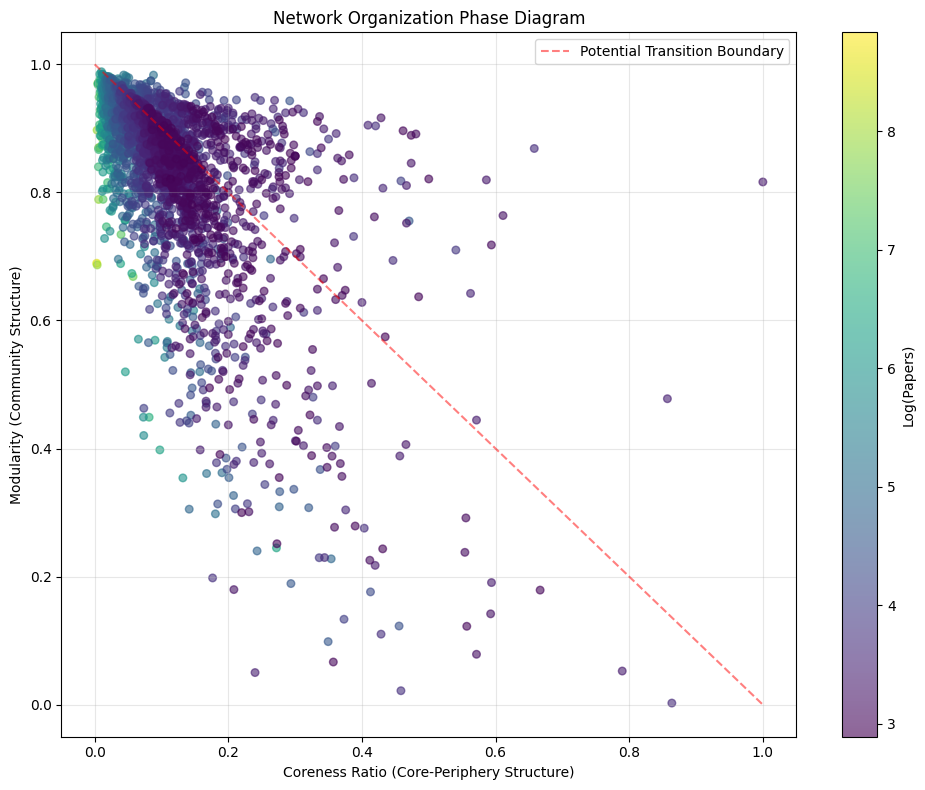

Total topics: 3046
Papers range: 18 - 6854
Modularity range: 0.003 - 0.988
Coreness range: 0.003 - 1.000


In [15]:
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load data
with open('results/collaboration_analysis/topic_analysis_10metrics_fixed_20250902_124913.json', 'r') as f:
    data = json.load(f)

# Convert to DataFrame
rows = []
for topic_id, metrics in data.items():
    if isinstance(metrics, dict) and 'modularity' in metrics:
        rows.append({
            'topic_id': topic_id,
            'modularity': metrics['modularity'],
            'coreness_ratio': metrics['coreness_ratio'],
            'total_papers': metrics['total_papers']
        })

df = pd.DataFrame(rows)

# Remove any invalid data
df = df.dropna()
df = df[(df['modularity'] >= 0) & (df['modularity'] <= 1)]
df = df[(df['coreness_ratio'] >= 0) & (df['coreness_ratio'] <= 1)]
# Add this to your existing script to find the transition boundary

# Define organizational regimes
df['regime'] = 'mixed'
df.loc[(df['coreness_ratio'] > 0.15) & (df['modularity'] < 0.6), 'regime'] = 'core_periphery'
df.loc[(df['coreness_ratio'] < 0.1) & (df['modularity'] > 0.7), 'regime'] = 'modular'

# Find the paper count threshold where regime switches
cp_papers = df[df['regime'] == 'core_periphery']['total_papers']
mod_papers = df[df['regime'] == 'modular']['total_papers']

print(f"Core-periphery topics: {cp_papers.min()}-{cp_papers.max()} papers (median: {cp_papers.median()})")
print(f"Modular topics: {mod_papers.min()}-{mod_papers.max()} papers (median: {mod_papers.median()})")

# Find the crossover point
threshold_estimate = (cp_papers.quantile(0.75) + mod_papers.quantile(0.25)) / 2
print(f"Estimated transition threshold: ~{threshold_estimate:.0f} papers")

# Create phase diagram
plt.figure(figsize=(10, 8))
scatter = plt.scatter(df['coreness_ratio'], df['modularity'], 
                     c=np.log(df['total_papers']), 
                     cmap='viridis', alpha=0.6, s=30)

plt.xlabel('Coreness Ratio (Core-Periphery Structure)')
plt.ylabel('Modularity (Community Structure)')
plt.title('Network Organization Phase Diagram')

# Add diagonal line showing potential transition boundary
x = np.linspace(0, 1, 100)
plt.plot(x, 1-x, 'r--', alpha=0.5, label='Potential Transition Boundary')

plt.colorbar(scatter, label='Log(Papers)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print some basic stats
print(f"Total topics: {len(df)}")
print(f"Papers range: {df['total_papers'].min()} - {df['total_papers'].max()}")
print(f"Modularity range: {df['modularity'].min():.3f} - {df['modularity'].max():.3f}")
print(f"Coreness range: {df['coreness_ratio'].min():.3f} - {df['coreness_ratio'].max():.3f}")

---

In [5]:
import pandas as pd

In [28]:
author_df = pd.read_csv('data/cleaned/author_topic_networks_disambiguated_v4.csv', low_memory=False)

In [29]:
author_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310068 entries, 0 to 310067
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   topic           310068 non-null  int64 
 1   id              310068 non-null  object
 2   authors_parsed  310068 non-null  object
 3   update_date     310068 non-null  object
dtypes: int64(1), object(3)
memory usage: 9.5+ MB


In [30]:
author_df.head()

,topic,id,authors_parsed,update_date
0,1199,705.0599,"[['Henry', 'Nathalie', ''], ['Fekete', 'Jean-D...",2020-08-04
1,62,705.1091,"[['Gonzalez-Avella', 'J.', 'C.'], ['Cosenza', ...",2024-11-05
2,1182,706.2194,"[['Lvov', 'Yuri', 'V'], ['Yokoyama', 'Naoto', ...",2020-06-10
3,98,706.3366,"[['Panja', 'Debabrata', ''], ['Selten', 'Frank...",2020-11-04
4,98,707.3547,"[['Bernacchia', 'Alberto', ''], ['Naveau', 'Ph...",2020-01-29


In [31]:
author_df['update_date'] = pd.to_datetime(author_df['update_date'])

In [32]:
author_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310068 entries, 0 to 310067
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   topic           310068 non-null  int64         
 1   id              310068 non-null  object        
 2   authors_parsed  310068 non-null  object        
 3   update_date     310068 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 9.5+ MB


In [47]:
topic_df = pd.read_csv('results/topics/topic_info_20250914_174642.csv')

topic_df.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,342733,-1_neural networks_datasets_modeling_generative,"['neural networks', 'datasets', 'modeling', 'g...","[""The Particle as a Statistical Ensemble of Ev..."
1,0,6902,0_power grid_power grids_smart grid_ev charging,"['power grid', 'power grids', 'smart grid', 'e...","[""Optimal Power Flow in Highly Renewable Power..."
2,1,5226,1_graphs bounded_planar graphs_graph classes_f...,"['graphs bounded', 'planar graphs', 'graph cla...",['Linear Size Universal Point Sets for Classes...
3,2,2883,2_discontinuous galerkin methods_galerkin meth...,"['discontinuous galerkin methods', 'galerkin m...","[""Optimal geometric multigrid preconditioners ..."
4,3,2854,3_sequential recommendation_recommendation mod...,"['sequential recommendation', 'recommendation ...",['Language-Model Prior Overcomes Cold-Start It...
5,4,2699,4_offline reinforcement rl_offline reinforceme...,"['offline reinforcement rl', 'offline reinforc...",['NeoRL: A Near Real-World Benchmark for Offli...
6,5,2428,5_covid 19 epidemic_epidemic models_covid 19 p...,"['covid 19 epidemic', 'epidemic models', 'covi...",['Superposition of waves for modeling COVID-19...
7,6,2074,6_causal discovery algorithms_causal discovery...,"['causal discovery algorithms', 'causal discov...",['Testing Identifiability and Transportability...
8,7,2072,7_medical text_clinical text_entity recognitio...,"['medical text', 'clinical text', 'entity reco...",['Efficient Standardization of Clinical Notes ...
9,8,1877,8_excitation energies_density functional theor...,"['excitation energies', 'density functional th...",['Accelerated basis-set convergence of coupled...


In [49]:
topic_df = topic_df[topic_df['Topic'] != -1]

In [50]:
cols = ['Topic','Count','Representation']

topic_df = topic_df[cols]

In [52]:
topic_df.to_csv('data/cleaned/cs_topic_keywords.csv')

In [54]:
topic_df['Representation']

1       ['power grid', 'power grids', 'smart grid', 'e...
2       ['graphs bounded', 'planar graphs', 'graph cla...
3       ['discontinuous galerkin methods', 'galerkin m...
4       ['sequential recommendation', 'recommendation ...
5       ['offline reinforcement rl', 'offline reinforc...
                              ...                        
3042    ['thermal radiation', 'thermal emitters', 'the...
3043    ['language models reinforcement', 'reinforceme...
3044    ['atom quantum computing', 'atom quantum compu...
3045    ['edge iot', 'things edge computing', 'iot edg...
3046    ['cross modal retrieval', 'multilingual multim...
Name: Representation, Length: 3046, dtype: object

In [57]:
classify_df = pd.read_csv('results/topics/topic_classification/llm_classifications.csv')

In [58]:
classify_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3046 entries, 0 to 3045
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   topic_id            3046 non-null   int64 
 1   classification      3046 non-null   object
 2   is_llm_related      3046 non-null   int64 
 3   confidence          3046 non-null   object
 4   is_high_confidence  3046 non-null   int64 
 5   keywords_joined     3046 non-null   object
 6   keywords_count      3046 non-null   int64 
 7   rationale           3046 non-null   object
 8   chatgpt_impact      3046 non-null   object
 9   key_keywords        3046 non-null   object
dtypes: int64(4), object(6)
memory usage: 238.1+ KB


In [62]:
classify_df.head(5)

,topic_id,classification,is_llm_related,confidence,is_high_confidence,keywords_joined,keywords_count,rationale,chatgpt_impact,key_keywords
0,0,CONTROL,0,High,1,power grid; smart grid; power systems,3,This topic is centered on electrical power sys...,The release of ChatGPT would have a negligible...,"['power grid', 'smart grid', 'power systems']"
1,1,CONTROL,0,High,1,planar graphs; graph classes; vertex cover,3,This topic deals with the mathematical and alg...,ChatGPT's release would have no direct impact ...,"['planar graphs', 'graph classes', 'vertex cov..."
2,2,CONTROL,0,High,1,discontinuous galerkin methods; finite element...,3,This topic focuses on numerical analysis and s...,The research is based on mathematical principl...,"['discontinuous galerkin methods', 'finite ele..."
3,3,LLM_RELATED,1,Medium,0,conversational recommender; sequential recomme...,3,While recommendation systems are a broad field...,ChatGPT would significantly impact this field ...,"['conversational recommender', 'sequential rec..."
4,4,CONTROL,0,Medium,0,offline reinforcement rl; policy gradient meth...,3,This topic focuses on the core algorithms of o...,The impact is indirect. The success of RLHF mi...,"['offline reinforcement rl', 'policy gradient ..."


In [71]:
manual_df = classify_df[classify_df['confidence'] != 'High']

manual_df.to_csv('results/topics/topic_classification/manual_review.csv')

In [72]:
topic_info_df = pd.read_csv('data/cleaned/cs_topics_info.csv')

In [73]:
topic_info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3046 entries, 0 to 3045
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0      3046 non-null   int64 
 1   Topic           3046 non-null   int64 
 2   Count           3046 non-null   int64 
 3   Representation  3046 non-null   object
 4   Classification  3046 non-null   object
 5   is_llm_related  3046 non-null   int64 
dtypes: int64(4), object(2)
memory usage: 142.9+ KB


In [74]:
topic_info_df[topic_info_df['Topic'] == 852]

,Unnamed: 0,Topic,Count,Representation,Classification,is_llm_related
852,852,852,87,"['arnold networks kans', 'arnold networks kan'...",LLM_RELATED,1


In [75]:
classification_switch = [852,1288,1882,1921,1439,1501,2110]

for topic in classification_switch:
    topic_info_df.loc[topic,['Classification','is_llm_related']] = ['CONTROL',0]

In [76]:
topic_info_df.head()

,Unnamed: 0,Topic,Count,Representation,Classification,is_llm_related
0,0,0,6902,"['power grid', 'power grids', 'smart grid', 'e...",CONTROL,0
1,1,1,5226,"['graphs bounded', 'planar graphs', 'graph cla...",CONTROL,0
2,2,2,2883,"['discontinuous galerkin methods', 'galerkin m...",CONTROL,0
3,3,3,2854,"['sequential recommendation', 'recommendation ...",LLM_RELATED,1
4,4,4,2699,"['offline reinforcement rl', 'offline reinforc...",CONTROL,0


In [77]:
print(topic_info_df.loc[classification_switch, ['Topic', 'Classification', 'is_llm_related']])

      Topic Classification  is_llm_related
852     852        CONTROL               0
1288   1288        CONTROL               0
1882   1882        CONTROL               0
1921   1921        CONTROL               0
1439   1439        CONTROL               0
1501   1501        CONTROL               0
2110   2110        CONTROL               0


In [78]:
topic_info_df.drop('Unnamed: 0', axis=1).to_csv('data/cleaned/cs_topics_info.csv', index=False)

In [80]:
topic_info_df[topic_info_df['is_llm_related'] != 1].nunique()

Unnamed: 0        2499
Topic             2499
Count              360
Representation    2499
Classification       1
is_llm_related       1
dtype: int64

In [2]:
import pandas as pd
all_df = pd.read_csv('data/cleaned/cs_arxiv_snapshot.csv',low_memory=False)

In [3]:
docs_df = pd.read_csv('results/topics/document_topics_20250914_174642.csv',low_memory=False)

In [6]:
all_df['update_date'] = pd.to_datetime(all_df['update_date'])

In [8]:
docs_df['published_date'] = pd.to_datetime(docs_df['published_date'])

In [10]:
print(all_df['update_date'].max())
print(docs_df[docs_df['topic'] != -1]['published_date'].max())

2025-05-30 00:00:00
2025-05-30 00:00:00


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

def analyze_papers_per_topic_distribution(documents_topics_path="results/topics/document_topics_20250914_174642.csv"):
    """
    Analyze the distribution of papers per topic over time to investigate
    the publication drop-off phenomenon.
    
    Parameters:
    - documents_topics_path: Path to your document_topics CSV file
    """
    
    print("="*80)
    print("PAPERS PER TOPIC DISTRIBUTION ANALYSIS")
    print("="*80)
    
    # Load documents_topics data
    try:
        df = pd.read_csv(documents_topics_path)
        print(f"✓ Loaded {len(df):,} papers from {documents_topics_path}")
    except FileNotFoundError:
        print(f"❌ File not found: {documents_topics_path}")
        return
    
    # Examine data structure  
    print(f"\n📊 DATA OVERVIEW:")
    print(f"Columns: {list(df.columns)}")
    print(f"Date range: {df['published_date'].min()} - {df['published_date'].max()}")
    print(f"Unique topics: {df['topic'].nunique():,}")
    print(f"Papers with topic -1 (outliers): {len(df[df['topic'] == -1]):,}")
    
    # Remove outlier topic (-1)
    df_clean = df[df['topic'] != -1].copy()
    print(f"Papers after removing outliers: {len(df_clean):,}")
    print(f"Valid topics: {df_clean['topic'].nunique():,}")
    
    # Create temporal columns
    df_clean['published_date'] = pd.to_datetime(df_clean['published_date'])
    df_clean['year'] = df_clean['published_date'].dt.year
    df_clean['quarter'] = df_clean['published_date'].dt.quarter
    df_clean['year_quarter'] = df_clean['year'].astype(str) + 'Q' + df_clean['quarter'].astype(str)
    
    # 1. Overall topic size distribution
    print(f"\n📈 TOPIC SIZE DISTRIBUTION:")
    topic_sizes = df_clean['topic'].value_counts().sort_values(ascending=False)
    
    print(f"Total topics: {len(topic_sizes):,}")
    print(f"Papers per topic statistics:")
    print(f"  Mean: {topic_sizes.mean():.1f}")
    print(f"  Median: {topic_sizes.median():.1f}")
    print(f"  Std: {topic_sizes.std():.1f}")
    print(f"  Min: {topic_sizes.min()}")
    print(f"  Max: {topic_sizes.max()}")
    
    # Topic size percentiles
    percentiles = [10, 25, 50, 75, 90, 95, 99]
    print(f"\nTopic size percentiles:")
    for p in percentiles:
        print(f"  {p:2d}th percentile: {np.percentile(topic_sizes, p):.0f} papers")
    
    # 2. Topic creation over time
    print(f"\n📅 TEMPORAL ANALYSIS:")
    
    # Find first appearance of each topic
    topic_birth = df_clean.groupby('topic')['year_quarter'].min().reset_index()
    topic_birth_counts = topic_birth['year_quarter'].value_counts().sort_index()
    
    print(f"New topics created per quarter (last 10):")
    for quarter, count in topic_birth_counts.tail(10).items():
        print(f"  {quarter}: {count} new topics")
    
    # Papers per quarter analysis
    quarterly_stats = df_clean.groupby('year_quarter').agg({
        'topic': ['count', 'nunique'],
        'id': 'count'
    }).round(2)
    
    quarterly_stats.columns = ['total_papers', 'unique_topics', 'total_papers_check']
    quarterly_stats['avg_papers_per_topic'] = quarterly_stats['total_papers'] / quarterly_stats['unique_topics']
    
    print(f"\nQuarterly statistics (last 8 quarters):")
    print(quarterly_stats.tail(8)[['total_papers', 'unique_topics', 'avg_papers_per_topic']])
    
    # Check for the specific drop-off pattern you observed
    print(f"\n🚨 INVESTIGATING THE DROP-OFF:")
    recent_quarters = sorted(df_clean['year_quarter'].unique())[-8:]
    
    for i, quarter in enumerate(recent_quarters):
        quarter_data = quarterly_stats.loc[quarter]
        if i > 0:
            prev_quarter = recent_quarters[i-1] 
            prev_data = quarterly_stats.loc[prev_quarter]
            change = ((quarter_data['avg_papers_per_topic'] / prev_data['avg_papers_per_topic']) - 1) * 100
            print(f"{quarter}: {quarter_data['avg_papers_per_topic']:.2f} avg papers/topic (change: {change:+.1f}%)")
        else:
            print(f"{quarter}: {quarter_data['avg_papers_per_topic']:.2f} avg papers/topic (baseline)")
            
    # 3. Topic fragmentation analysis
    print(f"\n🔍 TOPIC FRAGMENTATION ANALYSIS:")
    
    # Calculate topic sizes by quarter for active topics
    topic_quarterly = df_clean.groupby(['year_quarter', 'topic']).size().reset_index(name='papers_in_quarter')
    
    # Find topics that were active in multiple quarters
    topic_activity = topic_quarterly.groupby('topic')['year_quarter'].nunique()
    persistent_topics = topic_activity[topic_activity >= 4].index  # Topics active in 4+ quarters
    
    print(f"Topics active in 4+ quarters: {len(persistent_topics):,}")
    print(f"Topics active in only 1 quarter: {len(topic_activity[topic_activity == 1]):,}")
    
    # Analyze recent quarter patterns
    recent_quarters = sorted(df_clean['year_quarter'].unique())[-8:]  # Last 8 quarters
    
    for quarter in recent_quarters[-4:]:  # Last 4 quarters
        quarter_data = df_clean[df_clean['year_quarter'] == quarter]
        topic_sizes_q = quarter_data['topic'].value_counts()
        
        small_topics = len(topic_sizes_q[topic_sizes_q <= 2])  # Very small topics
        total_topics = len(topic_sizes_q)
        
        print(f"{quarter}: {total_topics:,} topics, {small_topics:,} with ≤2 papers ({small_topics/total_topics*100:.1f}%)")
    
    # 4. Potential issues diagnosis
    print(f"\n🔬 POTENTIAL ISSUES DIAGNOSIS:")
    
    # Check for topic proliferation
    recent_q = recent_quarters[-1]
    old_q = recent_quarters[0]
    
    recent_topics = set(df_clean[df_clean['year_quarter'] == recent_q]['topic'].unique())
    old_topics = set(df_clean[df_clean['year_quarter'] == old_q]['topic'].unique())
    
    new_topics = recent_topics - old_topics
    disappeared_topics = old_topics - recent_topics
    
    print(f"Comparing {old_q} vs {recent_q}:")
    print(f"  New topics appeared: {len(new_topics):,}")
    print(f"  Topics disappeared: {len(disappeared_topics):,}")
    print(f"  Topic overlap: {len(recent_topics & old_topics):,}")
    
    # Check for extremely small topics
    very_small_topics = topic_sizes[topic_sizes <= 5]
    print(f"\nVery small topics (≤5 papers): {len(very_small_topics):,} ({len(very_small_topics)/len(topic_sizes)*100:.1f}%)")
    
    if len(very_small_topics) > len(topic_sizes) * 0.5:
        print("⚠️  WARNING: High proportion of very small topics suggests possible over-fragmentation")
    
    # Investigate the drop-off: compare peak to recent
    peak_quarter_idx = quarterly_stats['avg_papers_per_topic'].idxmax()
    recent_quarter_idx = quarterly_stats.index[-1]
    
    peak_avg = quarterly_stats.loc[peak_quarter_idx, 'avg_papers_per_topic']
    recent_avg = quarterly_stats.loc[recent_quarter_idx, 'avg_papers_per_topic']
    drop_percent = ((recent_avg / peak_avg) - 1) * 100
    
    print(f"\n📉 DROP-OFF ANALYSIS:")
    print(f"Peak quarter: {peak_quarter_idx} with {peak_avg:.2f} avg papers/topic")
    print(f"Recent quarter: {recent_quarter_idx} with {recent_avg:.2f} avg papers/topic")
    print(f"Drop from peak: {drop_percent:.1f}%")
    
    # 5. Create visualizations
    create_distribution_plots(topic_sizes, df_clean)
    
    return {
        'topic_sizes': topic_sizes,
        'quarterly_stats': quarterly_stats,
        'df_clean': df_clean,
        'topic_birth_counts': topic_birth_counts,
        'topic_activity': topic_activity
    }

def create_distribution_plots(topic_sizes, df_clean):
    """Create visualization plots for topic distribution analysis."""
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Papers Per Topic Distribution Analysis', fontsize=16, fontweight='bold')
    
    # 1. Topic size histogram (log scale)
    axes[0,0].hist(topic_sizes, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0,0].set_xlabel('Papers per Topic')
    axes[0,0].set_ylabel('Number of Topics')
    axes[0,0].set_title('Distribution of Topic Sizes')
    axes[0,0].set_yscale('log')
    
    # 2. Cumulative distribution
    sorted_sizes = np.sort(topic_sizes)[::-1]
    cumulative_papers = np.cumsum(sorted_sizes)
    axes[0,1].plot(range(1, len(sorted_sizes)+1), cumulative_papers, 'b-', linewidth=2)
    axes[0,1].set_xlabel('Topic Rank')
    axes[0,1].set_ylabel('Cumulative Papers')
    axes[0,1].set_title('Cumulative Papers by Topic Rank')
    axes[0,1].grid(True, alpha=0.3)
    
    # 3. Topic size vs rank (power law check)
    axes[1,0].loglog(range(1, len(sorted_sizes)+1), sorted_sizes, 'ro', alpha=0.6, markersize=3)
    axes[1,0].set_xlabel('Topic Rank (log)')
    axes[1,0].set_ylabel('Papers per Topic (log)')
    axes[1,0].set_title('Topic Size vs Rank (Log-Log)')
    axes[1,0].grid(True, alpha=0.3)
    
    # 4. Temporal trend
    quarterly_topics = df_clean.groupby('year_quarter')['topic'].nunique()
    quarterly_papers = df_clean.groupby('year_quarter').size()
    quarterly_avg = quarterly_papers / quarterly_topics
    
    axes[1,1].plot(range(len(quarterly_avg)), quarterly_avg.values, 'g-o', linewidth=2, markersize=6)
    axes[1,1].set_xlabel('Quarter Index')
    axes[1,1].set_ylabel('Avg Papers per Topic')
    axes[1,1].set_title('Average Papers per Topic Over Time')
    axes[1,1].grid(True, alpha=0.3)
    
    # Add quarter labels for recent periods
    quarter_labels = quarterly_avg.index[-8:]  # Last 8 quarters
    label_positions = range(len(quarterly_avg)-8, len(quarterly_avg))
    if len(quarter_labels) > 0:
        axes[1,1].set_xticks(label_positions[::2])  # Every other label
        axes[1,1].set_xticklabels(quarter_labels[::2], rotation=45)
    
    # Highlight the drop-off
    peak_idx = np.argmax(quarterly_avg.values)
    axes[1,1].axvline(x=peak_idx, color='red', linestyle='--', alpha=0.7, label=f'Peak: {quarterly_avg.index[peak_idx]}')
    axes[1,1].legend()
    
    plt.tight_layout()
    plt.show()


PAPERS PER TOPIC DISTRIBUTION ANALYSIS
✓ Loaded 655,976 papers from results/topics/document_topics_20250914_174642.csv

📊 DATA OVERVIEW:
Columns: ['id', 'title', 'topic', 'published_date', 'primary_category']
Date range: 2020-01-01 - 2025-05-30
Unique topics: 3,047
Papers with topic -1 (outliers): 342,733
Papers after removing outliers: 313,243
Valid topics: 3,046

📈 TOPIC SIZE DISTRIBUTION:
Total topics: 3,046
Papers per topic statistics:
  Mean: 102.8
  Median: 47.0
  Std: 237.5
  Min: 20
  Max: 6902

Topic size percentiles:
  10th percentile: 22 papers
  25th percentile: 29 papers
  50th percentile: 47 papers
  75th percentile: 96 papers
  90th percentile: 209 papers
  95th percentile: 340 papers
  99th percentile: 839 papers

📅 TEMPORAL ANALYSIS:
New topics created per quarter (last 10):
  2022Q2: 16 new topics
  2022Q3: 8 new topics
  2022Q4: 8 new topics
  2023Q1: 13 new topics
  2023Q2: 17 new topics
  2023Q3: 9 new topics
  2023Q4: 11 new topics
  2024Q1: 2 new topics
  2024Q2:

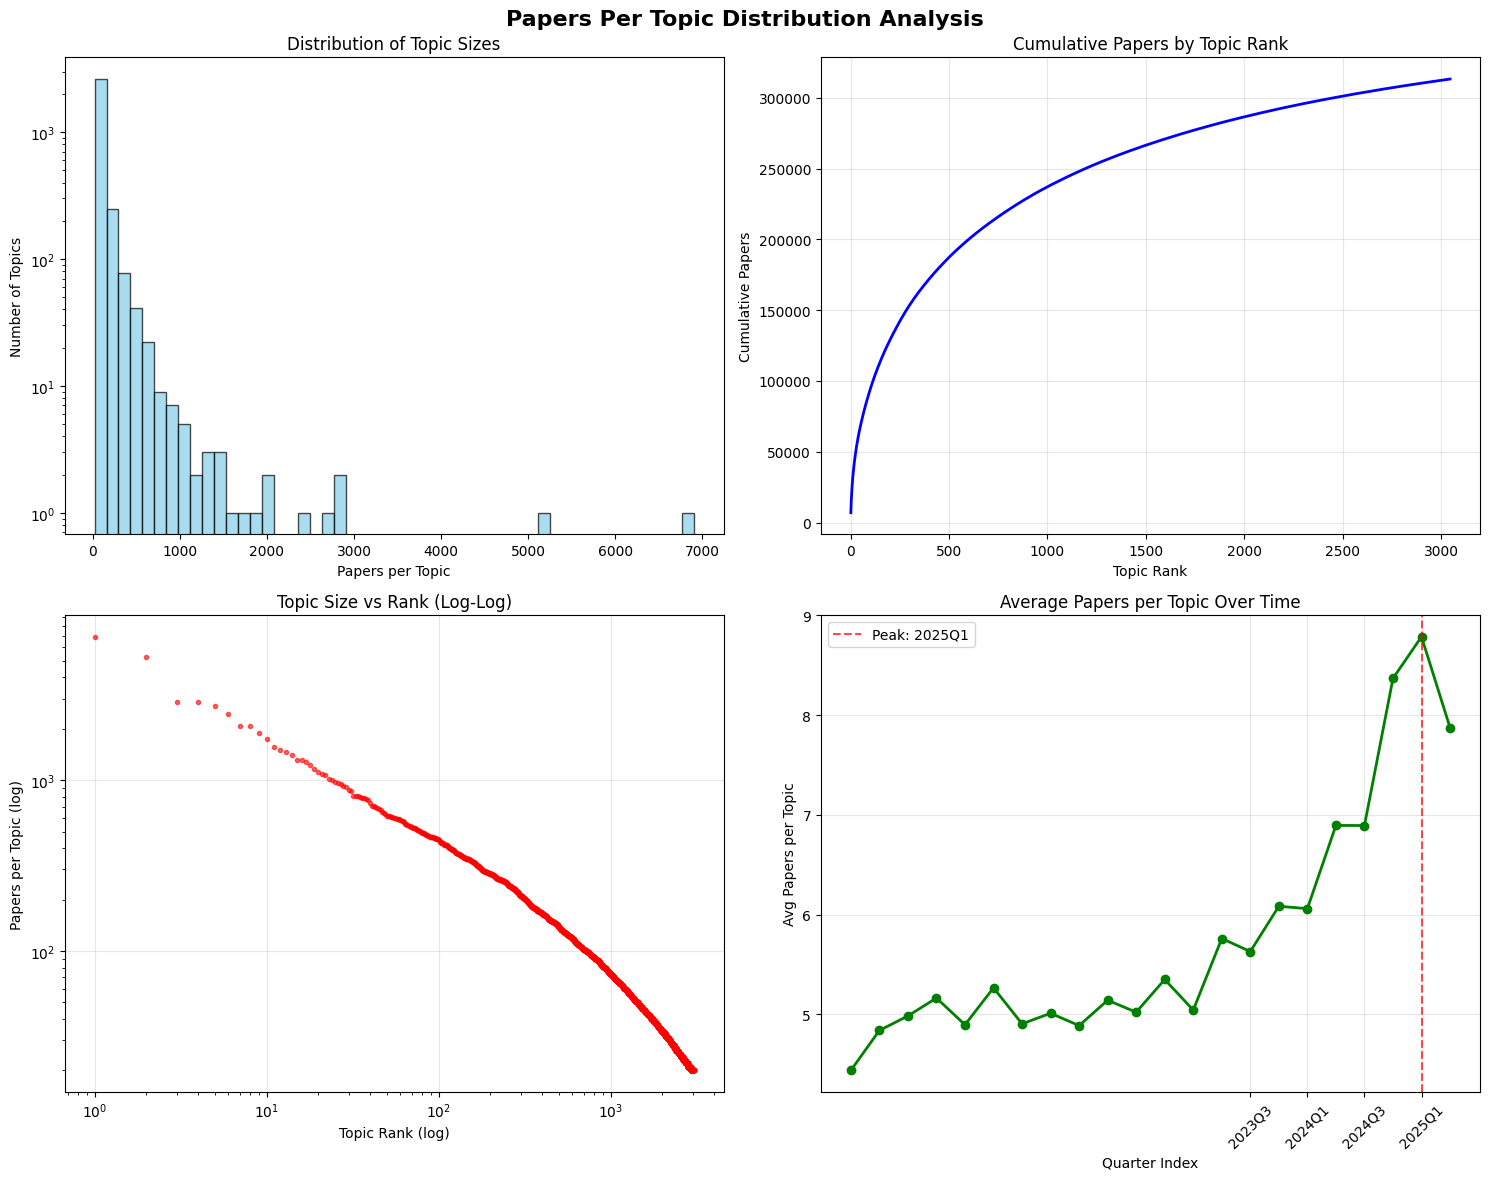

{'topic_sizes': topic
 0       6902
 1       5226
 2       2883
 3       2854
 4       2699
         ... 
 3012      20
 2951      20
 2943      20
 2958      20
 3028      20
 Name: count, Length: 3046, dtype: int64,
 'quarterly_stats':               total_papers  unique_topics  total_papers_check  \
 year_quarter                                                    
 2020Q1                8765           1975                8765   
 2020Q2               10331           2135               10331   
 2020Q3               10691           2145               10691   
 2020Q4               11200           2169               11200   
 2021Q1               10937           2234               10937   
 2021Q2               12175           2312               12175   
 2021Q3               11399           2324               11399   
 2021Q4               11585           2312               11585   
 2022Q1               11529           2359               11529   
 2022Q2               12067          

In [12]:
analyze_papers_per_topic_distribution()